# Forecasting MSFT 

For this project, MSFT stock market data will be forecast utilizing a combination of **Exponential Moving Averange(EMA)** and **Volume** as predictors. EMA **10, 50, and 200** are well known types of exponential moving averanges used to capture and predict trends in stock markets. The time series forecast will be computed by **Prohpet model**.

## Loading Libraries

In [1]:
#yahoo finance
import yfinance as yf
# Data manipulation
import pandas as pd
import numpy as np
##Plots
import matplotlib.pyplot as plt
import seaborn as sns

#Prophet model
from prophet import Prophet

# Accuracy
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from math import sqrt

## Loading Data

In [14]:
#Data ingestion
data = yf.download('MSFT', start='2000-01-01', end='2026-03-11')
data= data.asfreq('B')
data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2000-01-03,35.520367,36.148877,34.130025,35.767962,53228400.0
2000-01-04,34.320473,35.691768,34.206198,34.606159,54119000.0
2000-01-05,34.682369,35.463246,33.330119,33.863401,64059600.0
2000-01-06,33.520557,34.701395,33.025367,34.187159,54976600.0
2000-01-07,33.958618,34.206213,32.701597,33.101558,62013600.0
...,...,...,...,...,...
2026-03-04,405.200012,411.029999,400.309998,401.269989,35808000.0
2026-03-05,410.679993,411.609985,404.399994,404.420013,39001300.0


### Data Engineering

In [15]:
# Check if it is multiindex
if isinstance(data.columns,pd.MultiIndex):
    data.columns=data.columns.map(lambda x: x[0])

In [16]:
data.tail()

,Close,High,Low,Open,Volume
Date,,,,,
2026-03-04,405.200012,411.029999,400.309998,401.269989,35808000.0
2026-03-05,410.679993,411.609985,404.399994,404.420013,39001300.0
2026-03-06,408.959991,413.049988,408.510010,409.200012,31123900.0
2026-03-09,409.410004,410.209991,403.500000,404.920013,30073800.0
2026-03-10,405.475006,410.200012,402.940002,410.029999,16635586.0


In [17]:
data=data.reset_index()

In [19]:
data.head()

,Date,Close,High,Low,Open,Volume
0,2000-01-03,35.520367,36.148877,34.130025,35.767962,53228400.0
1,2000-01-04,34.320473,35.691768,34.206198,34.606159,54119000.0
2,2000-01-05,34.682369,35.463246,33.330119,33.863401,64059600.0
3,2000-01-06,33.520557,34.701395,33.025367,34.187159,54976600.0
4,2000-01-07,33.958618,34.206213,32.701597,33.101558,62013600.0


In [32]:
data=data.ffill()

In [68]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6633 entries, 199 to 6831
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      6633 non-null   datetime64[ns]
 1   y       6633 non-null   float64       
 2   High    6633 non-null   float64       
 3   Low     6633 non-null   float64       
 4   Open    6633 non-null   float64       
 5   Volume  6633 non-null   float64       
 6   ema10   6633 non-null   float64       
 7   ema50   6633 non-null   float64       
 8   ema200  6633 non-null   float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 518.2 KB


In [20]:
# rename columns for Prophet requeriments
data = data.rename(columns=({'Date':'ds','Close':'y'}))

## Exponential Moving Averanges

In [46]:
data['ema10']=data.y.ewm(min_periods=10,span=10).mean()
data['ema50']=data.y.ewm(min_periods=50,span=50).mean()
data['ema200']=data.y.ewm(min_periods=200,span=200).mean()

In [67]:
#delete missing values in emas 
data=data.dropna()

In [69]:
# train and test 
train, test = data[:-60], data[-60:]

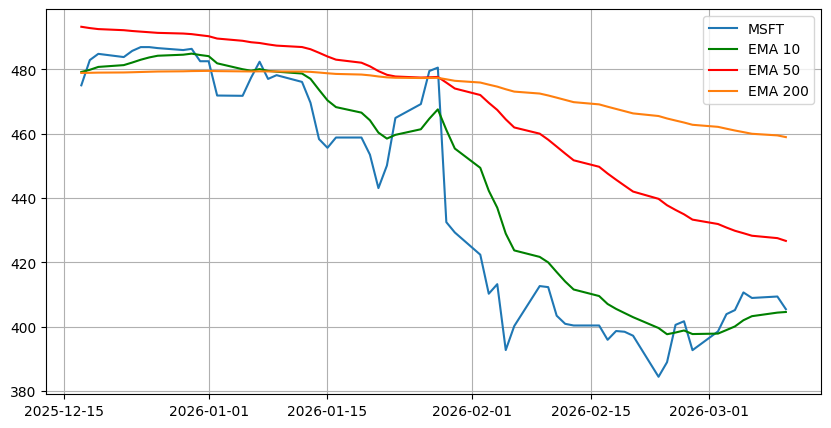

In [84]:
plt.figure(figsize=(10,5))
plt.plot(test['ds'], test['y'], label='MSFT')
plt.plot(test['ds'], test['ema10'], label='EMA 10', color='g')
plt.plot(test['ds'], test['ema50'], label='EMA 50', color='r')
plt.plot(test['ds'], test['ema200'], label='EMA 200')
plt.grid()
plt.legend()
plt.show()

### Prophet model

In [51]:
#Regressor
X=['Volume','ema10','ema50','ema200']

In [54]:
# model
model=Prophet()
# add regressor
for i in X:
    model.add_regressor(i, standardize='auto')

In [70]:
# fit the model
model.fit(train)

19:00:43 - cmdstanpy - INFO - Chain [1] start processing
19:00:48 - cmdstanpy - INFO - Chain [1] done processing


### Predict

In [71]:
pred=model.predict(test)

### Accuracy

In [72]:
#Accuracy
rmse= np.sqrt(mean_squared_error(test['y'],pred['yhat']))
mae=mean_absolute_error(test['y'],pred['yhat'])
r2 = r2_score(test['y'], pred['yhat'])
mape = mean_absolute_percentage_error(test['y'],pred['yhat'])

print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2}')
print(f'R2: {r2:.2}')
print(f'MAPE: {mape:.2}')

RMSE: 10.18
MAE: 7.8
R2: 0.92
MAPE: 0.018


### Plot Prediction VS Actual

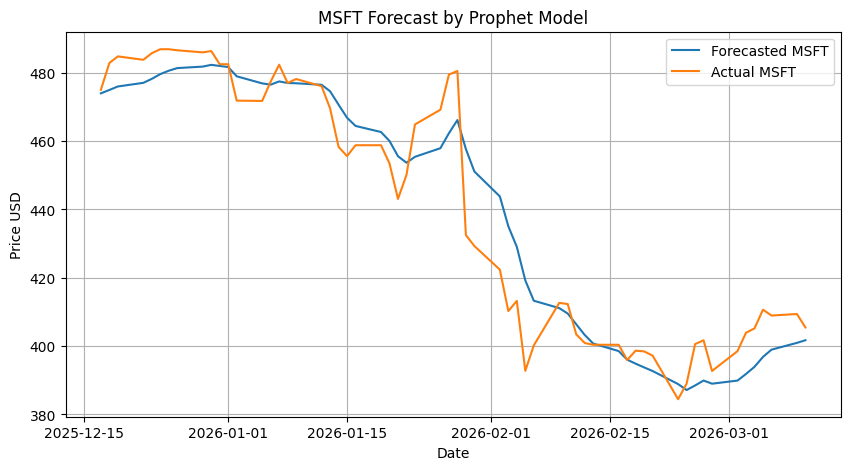

In [98]:
#plot
plt.figure(figsize=(10,5))
#plt.bar(test['ds'],test['Volume'])
plt.plot(test['ds'], pred['yhat'], label='Forecasted MSFT')
plt.plot(test['ds'],test['y'],label='Actual MSFT')
plt.title('MSFT Forecast by Prophet Model')
plt.grid()
plt.legend()
plt.xlabel('Date')
plt.ylabel('Price USD')
plt.show()

## Predicting Next Day Ahead

### Creating a dataframe with the next day

In [106]:
future=pd.DataFrame({
    'ds': pd.to_datetime(['2026-03-11']),
    'Volume':[data['Volume'].iloc[-1]],
    'ema10': [data['ema10'].iloc[-1]],
    'ema50':[data['ema50'].iloc[-1]],
    'ema200':[data['ema200'].iloc[-1]]
})

In [107]:
future

,ds,Volume,ema10,ema50,ema200
0,2026-03-11,16635586.0,404.602247,426.688751,458.93822


### Predict

In [139]:
forecast=model.predict(future)

In [140]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Volume,Volume_lower,Volume_upper,additive_terms,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2026-03-11,84.804509,398.474621,405.544576,84.804509,84.804509,0.213611,0.213611,0.213611,317.123401,...,14.029868,14.029868,14.029868,0.039573,0.039573,0.039573,0.0,0.0,0.0,401.927909


### Plot

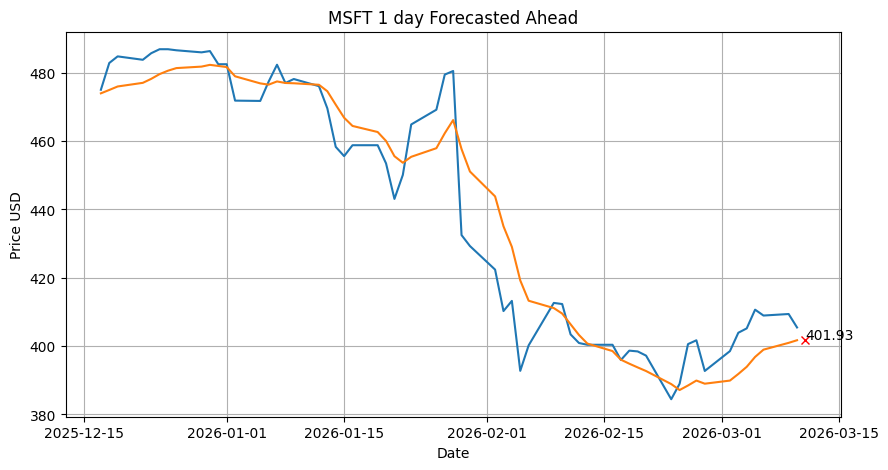

In [144]:
plt.figure(figsize=(10,5))
plt.plot(test['ds'],test['y'], label='Actual')
plt.plot(test['ds'],pred['yhat'], label='Forecasted')
plt.plot(forecast['ds'],forecast['yhat'],label='Prediction',marker='x', color='r')
for i, row in forecast.iterrows():
 plt.text(row['ds'],row['yhat'],f"{row['yhat']:.2f}", fontsize=10)
plt.title('MSFT 1 day Forecasted Ahead')
plt.xlabel('Date')
plt.ylabel('Price USD')
plt.grid()
plt.show()

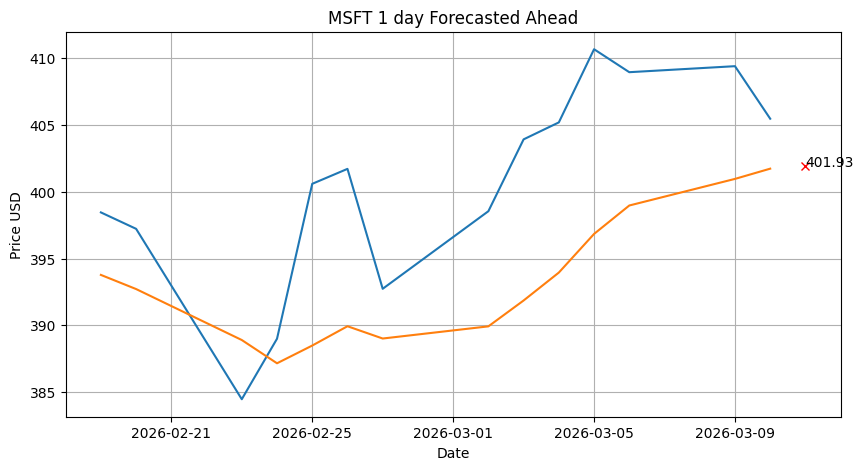

In [155]:
# last 14 days
plt.figure(figsize=(10,5))
plt.plot(test['ds'][-14:],test['y'][-14:], label='Actual')
plt.plot(test['ds'][-14:],pred['yhat'][-14:], label='Forecasted')
plt.plot(forecast['ds'][-14:],forecast['yhat'][-14:],label='Prediction',marker='x', color='r')
for i, row in forecast.iterrows():
 plt.text(row['ds'],row['yhat'],f"{row['yhat']:.2f}", fontsize=10)
plt.title('MSFT 1 day Forecasted Ahead')
plt.xlabel('Date')
plt.ylabel('Price USD')
plt.grid()
plt.show()